In [8]:
#step 1: import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
data= pd.DataFrame({
    "hours_studuied": np.random.randint(1,10,50),
    "attendance": np.random.randint(50,100,50)

})
data.head()

,hours_studuied,attendance
0,7,53
1,4,51
2,8,55
3,5,91
4,7,53


In [5]:
from sklearn.cluster import KMeans
x = data[["hours_studuied", "attendance"]]
model = KMeans(n_clusters=3, random_state=42, n_init=10)
data["cluster"] = model.fit_predict(x)

data.head()

,hours_studuied,attendance,cluster
0,7,53,1
1,4,51,1
2,8,55,1
3,5,91,0
4,7,53,1


In [9]:
score= silhouette_score(x, data["cluster"])
print("silhouette score:",score)

silhouette_score: 0.

silhouette score: 0.5276411515754762


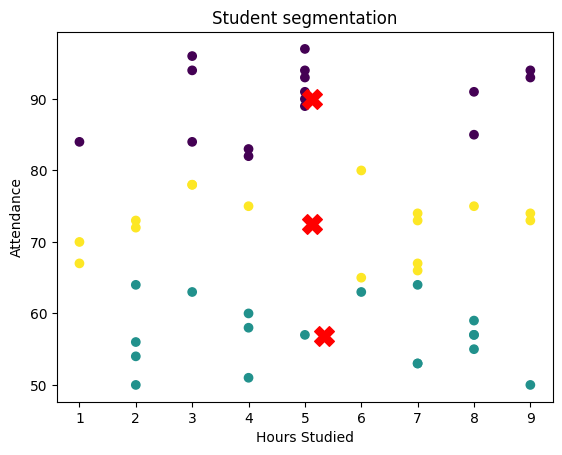

In [14]:
plt.scatter(data["hours_studuied"], data["attendance"], c=data["cluster"])
centers = model.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200, color='red')
plt.xlabel("Hours Studied")
plt.ylabel("Attendance")
plt.title("Student segmentation")
plt.show()

In [24]:
# Example: New student
# hours studied = 6, attendance = 80
new_student = [[6, 80]]
predicted_cluster = model.predict(new_student)
print("New student belongs to cluster:", predicted_cluster[0])

New student belongs to cluster: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [25]:
data.groupby("cluster").mean()


,hours_studuied,attendance
cluster,,
0,5.125000,90.000000
1,5.333333,56.888889
2,5.125000,72.500000
